In [1]:
import os
import random
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
CONFIG = {
    # --- paths ---
    "split_csv": Path("/kaggle/input/notebooks/syedjaffarrazakazmi/02-piyarathne-train-test-split-ipynb/piyarathne_split.csv"),
    "image_dir": Path("/kaggle/input/notebooks/syedjaffarrazakazmi/01-piyarathne-preprocessing-and-qc-ipynb/piyarathne/images"),

    "filename_col": "file_name",
    "label_col": "Category",
    "fold_col": "fold",
    "n_folds": 5,

    # --- this run's identity, used in logging so configs 2-7 don't overwrite each other ---
    "config_name": "config4_combined_augmentation",

    # --- model ---
    "backbone": "resnet50",
    "pretrained": True,
    "num_classes": 4,
    "image_size": 224,

    # --- training ---
    "batch_size": 32,
    "epochs": 30,
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "patience": 5,
    "num_workers": 2,

    # --- imbalance handling: OCA is 129 of 3000 images ---
    "use_class_weights": True,

    # --- output directories ---
    "checkpoint_dir": Path("/kaggle/working/checkpoints"),
    "results_log": Path("/kaggle/working/results/results_log.csv"),
    "oof_preds_path": Path("/kaggle/working/results/oof_predictions.csv"),
}

CONFIG["checkpoint_dir"].mkdir(parents=True, exist_ok=True)
CONFIG["results_log"].parent.mkdir(parents=True, exist_ok=True)

# Fixed label order, so class indices are identical across every fold and every config
CLASS_NAMES = ["Healthy", "Benign", "OPMD", "OCA"]
LABEL2IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
IDX2LABEL = {i: name for name, i in LABEL2IDX.items()}

df = pd.read_csv(CONFIG["split_csv"])
df["image_path"] = df[CONFIG["filename_col"]].apply(lambda f: str(CONFIG["image_dir"] / f))
df["label"] = df[CONFIG["label_col"]].map(LABEL2IDX)

assert df["label"].isna().sum() == 0, "Some Category values didn't map to a known class"

print("Shape:", df.shape)
print("\nClass distribution:")
print(df["label"].map(IDX2LABEL).value_counts())
print("\nFold distribution:")
print(pd.crosstab(df["fold"], df["label"].map(IDX2LABEL)))

Shape: (3000, 16)

Class distribution:
label
OPMD       1394
Benign      748
Healthy     729
OCA         129
Name: count, dtype: int64

Fold distribution:
label  Benign  Healthy  OCA  OPMD
fold                             
0         164      119   14   271
1         127      153   40   281
2         134      134   21   305
3         167      168   31   269
4         156      155   23   268


In [3]:
import torchvision.transforms as T

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class OCADataset(Dataset):
    def __init__(self, df, transform):
        self.paths = df["image_path"].tolist()
        self.labels = df["label"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.transform(img)
        label = self.labels[idx]
        return img, label

# --- Config-specific cell: this is the ONLY cell that changes between configs 1-7 ---
# Config 4: geometric + photometric combined. Same params as Config 2 and Config 3, just stacked.
train_transform = T.Compose([
    T.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(degrees=15, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Quick sanity check: load one image through the pipeline
sample_img, sample_label = OCADataset(df, eval_transform)[0]
print("Image tensor shape:", sample_img.shape)
print("Label:", sample_label, "->", IDX2LABEL[sample_label])

Image tensor shape: torch.Size([3, 224, 224])
Label: 2 -> OPMD


In [4]:
import timm

def build_model(backbone, num_classes, pretrained=True):
    model = timm.create_model(backbone, pretrained=pretrained, num_classes=num_classes)
    return model.to(device)

model = build_model(CONFIG["backbone"], CONFIG["num_classes"], CONFIG["pretrained"])
print(f"Built {CONFIG['backbone']} with {sum(p.numel() for p in model.parameters()):,} params")

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Built resnet50 with 23,516,228 params


In [5]:
def get_class_weights(train_df, num_classes):
    counts = train_df["label"].value_counts().sort_index()
    weights = (1.0 / counts).reindex(range(num_classes)).fillna(0)
    weights = weights / weights.sum() * num_classes
    return torch.tensor(weights.values, dtype=torch.float32).to(device)

def build_criterion(train_df, config):
    if config["use_class_weights"]:
        class_weights = get_class_weights(train_df, config["num_classes"])
    else:
        class_weights = None
    return nn.CrossEntropyLoss(weight=class_weights)

def build_optimizer_and_scheduler(model, config):
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs"])
    return optimizer, scheduler

# Quick check on the full dataset's weights, just to see the scale
_test_weights = get_class_weights(df, CONFIG["num_classes"])
print("Class weights (Healthy, Benign, OPMD, OCA):", _test_weights.cpu().numpy())

Class weights (Healthy, Benign, OPMD, OCA): [0.4908748  0.47840607 0.2567057  2.7740135 ]


In [6]:
from sklearn.metrics import accuracy_score, f1_score

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    torch.set_grad_enabled(is_train)
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, macro_f1, all_preds, all_labels


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, config, fold_idx):
    best_val_f1 = -1
    epochs_no_improve = 0
    history = []
    ckpt_path = config["checkpoint_dir"] / f"{config['config_name']}_fold{fold_idx}_best.pt"

    for epoch in range(1, config["epochs"] + 1):
        t0 = time.time()
        train_loss, train_acc, train_f1, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_f1, _, _ = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step()
        elapsed = time.time() - t0

        print(f"  Epoch {epoch:02d} | train_loss {train_loss:.4f} f1 {train_f1:.4f} "
              f"| val_loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} | {elapsed:.1f}s")

        history.append({"epoch": epoch, "train_loss": train_loss, "train_f1": train_f1,
                         "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1})

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            epochs_no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= config["patience"]:
                print(f"  Early stopping at epoch {epoch}")
                break

    return history, best_val_f1, ckpt_path

In [7]:
from PIL import Image
import os

CACHE_DIR = Path("/kaggle/working/cache_256")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_SIZE = 256  # slightly larger than the 224 training size, leaves room for random-crop augmentation configs later

def build_cache(df, cache_dir, cache_size):
    unique_paths = df["image_path"].unique()
    print(f"Caching {len(unique_paths)} unique images to {cache_dir} at {cache_size}x{cache_size}...")
    t0 = time.time()
    for i, src_path in enumerate(unique_paths):
        dst_path = cache_dir / Path(src_path).name
        if dst_path.exists():
            continue
        img = Image.open(src_path).convert("RGB")
        img = img.resize((cache_size, cache_size), Image.BILINEAR)
        img.save(dst_path, quality=90)
        if (i + 1) % 500 == 0:
            print(f"  {i+1}/{len(unique_paths)} done, {time.time()-t0:.0f}s elapsed")
    print(f"Cache built in {time.time()-t0:.0f}s")

build_cache(df, CACHE_DIR, CACHE_SIZE)

# Point image_path at the cached, pre-resized copies instead of the originals
df["image_path"] = df["file_name"].apply(lambda f: str(CACHE_DIR / f))

# Re-verify one image loads correctly from cache
sample_img, sample_label = OCADataset(df, eval_transform)[0]
print("Cached image tensor shape:", sample_img.shape)

Caching 3000 unique images to /kaggle/working/cache_256 at 256x256...
  500/3000 done, 86s elapsed
  1000/3000 done, 186s elapsed
  1500/3000 done, 256s elapsed
  2000/3000 done, 323s elapsed
  2500/3000 done, 402s elapsed
  3000/3000 done, 467s elapsed
Cache built in 467s
Cached image tensor shape: torch.Size([3, 224, 224])


In [8]:
import shutil
from pathlib import Path

nb5_log = Path("/kaggle/input/notebooks/syedjaffarrazakazmi/05-config3-photometric-augmentation") / "results" / "results_log.csv"

print("Looking for:", nb5_log)
print("Exists:", nb5_log.exists())

if nb5_log.exists() and not CONFIG["results_log"].exists():
    CONFIG["results_log"].parent.mkdir(parents=True, exist_ok=True)
    shutil.copy(nb5_log, CONFIG["results_log"])
    print("Copied Config 1, 2, and 3's results log forward.")
elif CONFIG["results_log"].exists():
    print("results_log.csv already exists in working dir, skipping copy to avoid overwrite.")
else:
    print("Source file not found, check the path above.")

Looking for: /kaggle/input/notebooks/syedjaffarrazakazmi/05-config3-photometric-augmentation/results/results_log.csv
Exists: True
Copied Config 1, 2, and 3's results log forward.


In [9]:
oof_preds = np.full(len(df), -1, dtype=int)
oof_probs = np.zeros((len(df), CONFIG["num_classes"]), dtype=float)
fold_val_f1s = []
fold_histories = {}
fold_ckpt_paths = {}

for fold_idx in range(CONFIG["n_folds"]):
    print(f"\n{'='*60}\nFold {fold_idx}\n{'='*60}")

    train_df = df[df["fold"] != fold_idx].reset_index(drop=True)
    val_df = df[df["fold"] == fold_idx].reset_index(drop=True)
    val_indices = df.index[df["fold"] == fold_idx].to_numpy()

    train_ds = OCADataset(train_df, train_transform)
    val_ds = OCADataset(val_df, eval_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                               num_workers=CONFIG["num_workers"], pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                             num_workers=CONFIG["num_workers"], pin_memory=True)

    # Fresh model, criterion, optimizer, scheduler every fold, no carryover between folds
    model = build_model(CONFIG["backbone"], CONFIG["num_classes"], CONFIG["pretrained"])
    criterion = build_criterion(train_df, CONFIG)
    optimizer, scheduler = build_optimizer_and_scheduler(model, CONFIG)

    history, best_val_f1, ckpt_path = train_model(
        model, train_loader, val_loader, criterion, optimizer, scheduler, CONFIG, fold_idx
    )
    fold_histories[fold_idx] = history
    fold_val_f1s.append(best_val_f1)
    fold_ckpt_paths[fold_idx] = ckpt_path

    # Reload best checkpoint for this fold, generate OOF predictions on its val split
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    fold_probs = []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)
            fold_probs.append(probs.cpu().numpy())
    fold_probs = np.concatenate(fold_probs, axis=0)

    oof_probs[val_indices] = fold_probs
    oof_preds[val_indices] = fold_probs.argmax(axis=1)

    print(f"Fold {fold_idx} best val macro-F1: {best_val_f1:.4f}")

assert (oof_preds != -1).all(), "Some rows never got an OOF prediction, check fold assignment"
print(f"\nPer-fold val macro-F1: mean {np.mean(fold_val_f1s):.4f}, std {np.std(fold_val_f1s):.4f}")
print("Per-fold scores:", [round(f, 4) for f in fold_val_f1s])


Fold 0
  Epoch 01 | train_loss 1.3726 f1 0.3046 | val_loss 1.3204 acc 0.4842 f1 0.3647 | 28.7s
  Epoch 02 | train_loss 1.2501 f1 0.4125 | val_loss 1.1903 acc 0.4542 f1 0.3841 | 28.2s
  Epoch 03 | train_loss 1.0348 f1 0.4697 | val_loss 1.2769 acc 0.3856 f1 0.3168 | 29.0s
  Epoch 04 | train_loss 0.8744 f1 0.5551 | val_loss 1.1823 acc 0.4877 f1 0.3991 | 28.6s
  Epoch 05 | train_loss 0.7642 f1 0.6219 | val_loss 1.1823 acc 0.5211 f1 0.4521 | 28.5s
  Epoch 06 | train_loss 0.6889 f1 0.6618 | val_loss 1.3065 acc 0.4718 f1 0.4434 | 28.8s
  Epoch 07 | train_loss 0.6112 f1 0.7217 | val_loss 1.1877 acc 0.5317 f1 0.4727 | 28.6s
  Epoch 08 | train_loss 0.5201 f1 0.7583 | val_loss 1.3045 acc 0.5246 f1 0.4774 | 28.7s
  Epoch 09 | train_loss 0.4485 f1 0.7993 | val_loss 1.2466 acc 0.5088 f1 0.4621 | 28.8s
  Epoch 10 | train_loss 0.4114 f1 0.8150 | val_loss 1.3572 acc 0.5563 f1 0.4975 | 28.6s
  Epoch 11 | train_loss 0.3552 f1 0.8310 | val_loss 1.3651 acc 0.5423 f1 0.4945 | 28.7s
  Epoch 12 | train_loss 

In [10]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

oof_acc = accuracy_score(df["label"], oof_preds)
oof_macro_f1 = f1_score(df["label"], oof_preds, average="macro")
precision, recall, f1_per_class, support = precision_recall_fscore_support(
    df["label"], oof_preds, labels=list(range(CONFIG["num_classes"]))
)
cm = confusion_matrix(df["label"], oof_preds, labels=list(range(CONFIG["num_classes"])))

print(f"Pooled OOF accuracy: {oof_acc:.4f}")
print(f"Pooled OOF macro-F1: {oof_macro_f1:.4f}")
print(f"\nPer-fold mean {np.mean(fold_val_f1s):.4f}, std {np.std(fold_val_f1s):.4f} (secondary stability check)")

print("\nPer-class metrics (pooled OOF):")
for c in range(CONFIG["num_classes"]):
    print(f"  {IDX2LABEL[c]:>8s}: precision {precision[c]:.4f}, recall {recall[c]:.4f}, "
          f"f1 {f1_per_class[c]:.4f}, support {support[c]}")

print("\nConfusion matrix (rows=true, cols=pred):")
print("        ", "  ".join(f"{IDX2LABEL[c]:>8s}" for c in range(CONFIG["num_classes"])))
for i, row in enumerate(cm):
    print(f"{IDX2LABEL[i]:>8s}", "  ".join(f"{v:8d}" for v in row))

# --- Log this config's result to the shared comparison table ---
result_row = {
    "config_name": CONFIG["config_name"],
    "backbone": CONFIG["backbone"],
    "oof_accuracy": oof_acc,
    "oof_macro_f1": oof_macro_f1,
    "per_fold_f1_mean": np.mean(fold_val_f1s),
    "per_fold_f1_std": np.std(fold_val_f1s),
}
for c in range(CONFIG["num_classes"]):
    result_row[f"{IDX2LABEL[c]}_precision"] = precision[c]
    result_row[f"{IDX2LABEL[c]}_recall"] = recall[c]
    result_row[f"{IDX2LABEL[c]}_f1"] = f1_per_class[c]

if CONFIG["results_log"].exists():
    log_df = pd.read_csv(CONFIG["results_log"])
    log_df = pd.concat([log_df, pd.DataFrame([result_row])], ignore_index=True)
else:
    log_df = pd.DataFrame([result_row])
log_df.to_csv(CONFIG["results_log"], index=False)

# --- Save the raw OOF predictions too, useful later for error analysis or ensembling ---
oof_df = df[["file_name", "patient_id", "fold", "label"]].copy()
oof_df["label_name"] = oof_df["label"].map(IDX2LABEL)
oof_df["pred"] = oof_preds
oof_df["pred_name"] = oof_df["pred"].map(IDX2LABEL)
for c in range(CONFIG["num_classes"]):
    oof_df[f"prob_{IDX2LABEL[c]}"] = oof_probs[:, c]
oof_df.to_csv(CONFIG["oof_preds_path"], index=False)

print(f"\nLogged to {CONFIG['results_log']}")
print(f"OOF predictions saved to {CONFIG['oof_preds_path']}")
log_df

Pooled OOF accuracy: 0.5850
Pooled OOF macro-F1: 0.5372

Per-fold mean 0.5300, std 0.0346 (secondary stability check)

Per-class metrics (pooled OOF):
   Healthy: precision 0.5550, recall 0.6433, f1 0.5959, support 729
    Benign: precision 0.4854, recall 0.4906, f1 0.4880, support 748
      OPMD: precision 0.6784, recall 0.6220, f1 0.6490, support 1394
       OCA: precision 0.4298, recall 0.4031, f1 0.4160, support 129

Confusion matrix (rows=true, cols=pred):
          Healthy    Benign      OPMD       OCA
 Healthy      469       101       155         4
  Benign      132       367       218        31
    OPMD      243       250       867        34
     OCA        1        38        38        52

Logged to /kaggle/working/results/results_log.csv
OOF predictions saved to /kaggle/working/results/oof_predictions.csv


,config_name,backbone,oof_accuracy,oof_macro_f1,per_fold_f1_mean,per_fold_f1_std,Healthy_precision,Healthy_recall,Healthy_f1,Benign_precision,Benign_recall,Benign_f1,OPMD_precision,OPMD_recall,OPMD_f1,OCA_precision,OCA_recall,OCA_f1
0,config1_no_augmentation,resnet50,0.583000,0.489256,0.482956,0.028428,0.612392,0.582990,0.597330,0.488189,0.497326,0.492715,0.636301,0.666428,0.651016,0.273810,0.178295,0.215962
1,config2_geometric_augmentation,resnet50,0.588000,0.519547,0.515650,0.024023,0.572438,0.666667,0.615970,0.489011,0.475936,0.482385,0.664168,0.635581,0.649560,0.404494,0.279070,0.330275
2,config3_photometric_augmentation,resnet50,0.563333,0.511862,0.507646,0.022731,0.546005,0.618656,0.580064,0.452645,0.491979,0.471493,0.662390,0.592539,0.625521,0.394737,0.348837,0.370370
3,config4_combined_augmentation,resnet50,0.585000,0.537229,0.530047,0.034630,0.555030,0.643347,0.595934,0.485450,0.490642,0.488032,0.678404,0.621951,0.648952,0.429752,0.403101,0.416000


OCA images: 129 total, 52 correct, 77 misclassified

Where the misclassified OCA images ended up:
pred_name
Benign     38
OPMD       38
Healthy     1
Name: count, dtype: int64

Top 10 most confidently wrong OCA predictions:
   file_name Clinical Diagnosis pred_name  confidence_in_wrong_pred     prob_OCA
R-163-01.jpg        Oral Cancer    Benign                  0.999975 3.230005e-07
R-163-03.jpg        Oral Cancer    Benign                  0.999907 1.260853e-05
N-352-02.jpg        Oral Cancer    Benign                  0.997846 1.519208e-03
R-163-07.jpg        Oral Cancer    Benign                  0.995961 2.523747e-04
R-252-05.jpg        Oral Cancer    Benign                  0.993032 6.022149e-04
R-181-03.jpg        Oral Cancer    Benign                  0.992791 2.239873e-06
 S-82-01.jpg        Oral Cancer      OPMD                  0.992282 2.852363e-03
S-173-01.jpg        Oral Cancer      OPMD                  0.991954 6.728918e-05
S-176-01.jpg        Oral Cancer      OPMD      

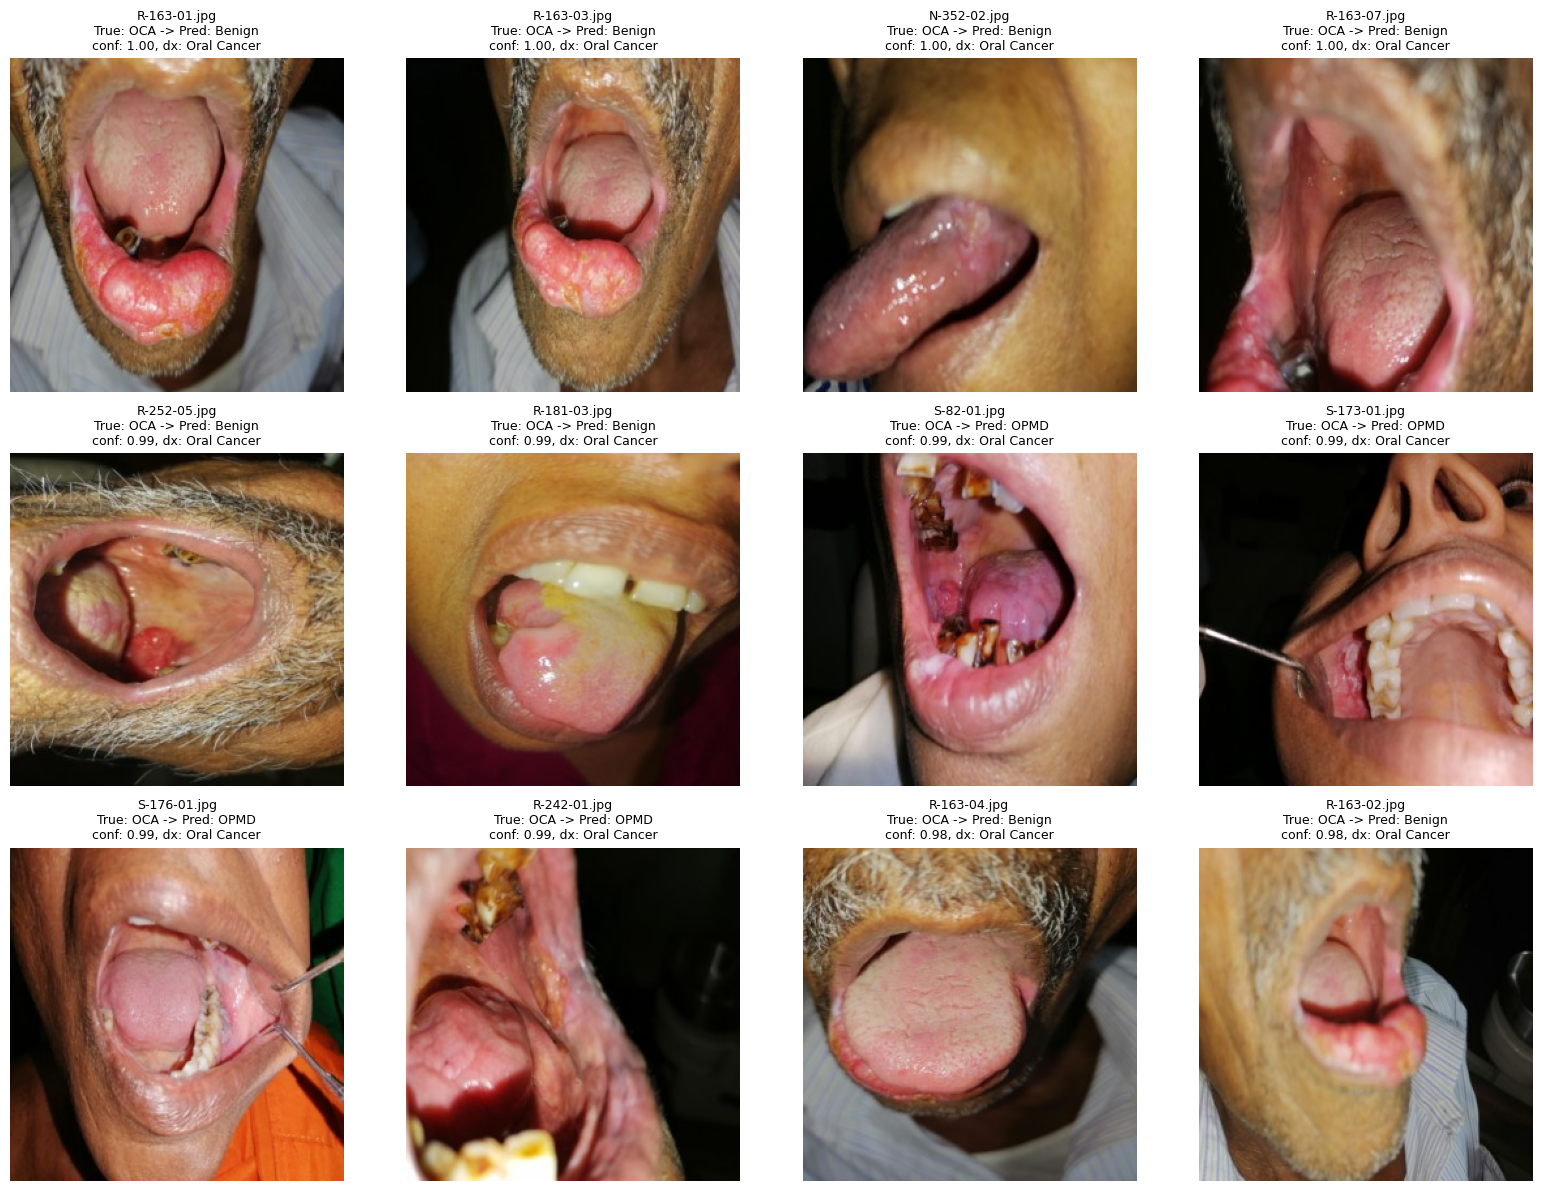

In [11]:
import matplotlib.pyplot as plt

oof_df = pd.read_csv(CONFIG["oof_preds_path"])

oca_true = oof_df[oof_df["label_name"] == "OCA"].copy()
oca_correct = oca_true[oca_true["pred_name"] == "OCA"]
oca_wrong = oca_true[oca_true["pred_name"] != "OCA"]

print(f"OCA images: {len(oca_true)} total, {len(oca_correct)} correct, {len(oca_wrong)} misclassified")
print("\nWhere the misclassified OCA images ended up:")
print(oca_wrong["pred_name"].value_counts())

# Merge back patient_id and clinical diagnosis for context, if available in df
oca_wrong = oca_wrong.merge(
    df[["file_name", "Clinical Diagnosis"]].drop_duplicates("file_name"),
    on="file_name", how="left"
)

# Sort by model confidence in its (wrong) prediction, highest confidence wrong answers are most interesting
oca_wrong["confidence_in_wrong_pred"] = oca_wrong.apply(
    lambda row: row[f"prob_{row['pred_name']}"], axis=1
)
oca_wrong = oca_wrong.sort_values("confidence_in_wrong_pred", ascending=False)

print("\nTop 10 most confidently wrong OCA predictions:")
print(oca_wrong[["file_name", "Clinical Diagnosis", "pred_name", "confidence_in_wrong_pred", "prob_OCA"]].head(10).to_string(index=False))

# Visualize the 12 most confidently wrong ones
n_show = min(12, len(oca_wrong))
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, (_, row) in zip(axes.flat, oca_wrong.head(n_show).iterrows()):
    img_path = CACHE_DIR / row["file_name"]
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"{row['file_name']}\nTrue: OCA -> Pred: {row['pred_name']}\n"
                 f"conf: {row['confidence_in_wrong_pred']:.2f}, dx: {row['Clinical Diagnosis']}",
                 fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()